## Quantamental Long-Short Equity Strategy ##

* This strategy is based on the AQR white paper: "The Case for Core Equity" https://www.anderson.ucla.edu/documents/sites/about/clubs/asam/4-AQR-A-New-Core-Equity-Paradigm.pdf 

* S&P500 constituents, stock prices and financial data are sourced from WRDS, a reliable and academic data source.

* Overview: The strategy aims to rank and score stocks based on Value, Momentum, and Quality (Profitability) factors, constructing a long-only portfolio of only the highest scoring stocks.

* Original testing period: 1980 - 2012.

#### Strategy: ####

1.  **Choose a stock universe** (US 1000 large cap, US 2000 small cap, International large cap equities (Top 85% of market cap from twenty developed markets))

2. **Rank Stocks based on these factors:**

    * **Value.** Value is computed using: 1. P/B ratio; 2. P/E ratio; 3. Forward P/E ratio; 4. EV / FCF; 5. EV / Sales

    * **Quality** (profitability). Profitability is computed using: 1. ROA; 2. FCF-to-Assets; 3. Gross Profit Margins

    * **Momentum.** Momentum is computed using: 1. Trailing 12-1 month return*; 2. 3-day average returns around earnings announcements over prior year

3. **Scoring**
    - Standardize and average metrics within each factor
    - Compute stock-level ranks for Value, Quality, and Momentum

4. **Use a 40%, 40%, 20% weighting on Value, Momentum, and Profitability.**

5. **Select top 25% of ranked stocks and weight them 50/50 based on market cap and score.**

6. **Recalculate the stock ranks and rebalance the portfolio quarterly.**



Note: The 12-1 momentum definition uses a one-month skip to reduce short-term reversal effects (Chan, Jegadeesh, and Lakonishok, 1997).


#### My Strategy Modifications ####
* Use FCF/OCF, ROE, and ROA for the profitability score
* Use P/B ratio and P/E ratio for the value score 
* Use trailing 1 month return only for the momentum score
* Long the top 15%  and short the bottom 15% scores for market neutrality
* Add short book of 10% of the bottom scoring stocks
* Use Universe of 500 stocks (S&P500)
* Rebalance monthly instead of quarterly

### Future Improvements

- Implement global minimum variance optimization on ranked stocks
- Replace trailing P/E with forward P/E
- Add earnings-announcement return effects to the momentum factor
- Test 12-1 month momentum factor & quarterly rebalancing
- Implement a small 10% weighting for sentiment

In [45]:
# Core data wrangling
import pandas as pd
import numpy as np
from pathlib import Path

# WRDS access
import wrds

# Plotting backtest results
import matplotlib.pyplot as plt

# Stats for z-scoring / winsorizing
from scipy import stats

### 1. Data Pulling & Cleaning ###

In [46]:
# Time
START = "2015-01-01"
END   = "2025-12-31"

# Rebalance: month-end
REBAL = "M"

# Cache folder for WRDS pulls
CACHE = Path("./wrds_cache"); CACHE.mkdir(exist_ok=True)

# Connect to WRDS (prompts for username/password the first time only)
db = wrds.Connection()

# Tiny cache helper: pull once, then read parquet on reruns
def pull(name, sql, date_cols=None):
    f = CACHE / f"{name}.parquet"
    if f.exists():
        return pd.read_parquet(f)
    df = db.raw_sql(sql, date_cols=date_cols)
    df.to_parquet(f)
    return df

WRDS recommends setting up a .pgpass file.
pgpass file created at C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [73]:
# Clear cached WRDS parquet files so schema changes are picked up on rerun
for parquet_file in CACHE.glob('*.parquet'): 
    parquet_file.unlink(missing_ok=True)

In [74]:
# --- 1. S&P 500 historical membership ---
sp500 = pull("sp500", f"""
    SELECT permno, start, ending
    FROM crsp.dsp500list
    WHERE ending >= '{START}'
""", date_cols=["start", "ending"])

# --- 2. Monthly prices (with ticker + common-stock filter) ---
permnos = tuple(int(p) for p in sp500.permno.unique())
prices = pull("prices", f"""
    SELECT d.permno, n.ticker, d.date, d.prc, d.ret, d.shrout, d.vol
    FROM crsp.msf AS d
    INNER JOIN crsp.msenames AS n
      ON d.permno = n.permno
     AND d.date >= n.namedt
     AND d.date <= n.nameendt
    WHERE d.permno IN {permnos}
      AND d.date BETWEEN '{START}' AND '{END}'
      AND n.shrcd IN (10, 11)
      AND n.exchcd IN (1, 2, 3)
""", date_cols=["date"])
# Dedupe boundary-date duplicates from msenames join (keep most recent ticker)
prices = prices.drop_duplicates(subset=['permno', 'date'], keep='last')

# --- 3. Financial ratios ---
ratios = pull("ratios", f"""
    SELECT permno, public_date, ptb, pe_exi, opmbd, roe, roa, fcf_ocf
    FROM wrdsapps.firm_ratio
    WHERE permno IN {permnos}
      AND public_date BETWEEN '{START}' AND '{END}'
""", date_cols=["public_date"])
ratios = ratios.drop_duplicates(subset=['permno', 'public_date'], keep='last')

# --- Sanity checks ---
print(f"sp500  rows: {len(sp500):>8,}   unique permnos: {sp500.permno.nunique():,}")
print(f"prices rows: {len(prices):>8,}   range: {prices.date.min().date()} -> {prices.date.max().date()}")
print(f"ratios rows: {len(ratios):>8,}   unique permnos: {ratios.permno.nunique():,}")
print(f"prices dup (permno, date): {prices.duplicated(['permno', 'date']).sum()}")
print(f"ratios dup (permno, public_date): {ratios.duplicated(['permno', 'public_date']).sum()}")
print("\nratios sample:"); print(ratios.head(3))

In [71]:
# --- Membership spine: (permno, month_end) for every month a stock was in S&P 500 ---
month_ends = pd.date_range(START, END, freq='ME')

spine_rows = []
for _, r in sp500.iterrows():
    valid = month_ends[(month_ends >= r['start']) & (month_ends <= r['ending'])]
    spine_rows.extend((r['permno'], d) for d in valid)
spine = pd.DataFrame(spine_rows, columns=['permno', 'month_end'])

spine['ym']  = spine['month_end'].dt.to_period('M')
prices['ym'] = prices['date'].dt.to_period('M')
ratios['ym'] = ratios['public_date'].dt.to_period('M')

panel = (
    spine
    .merge(prices[['permno', 'ticker', 'ym', 'prc', 'ret', 'shrout', 'vol']],
           on=['permno', 'ym'], how='left')
    .merge(ratios[['permno', 'ym', 'ptb', 'pe_exi', 'opmbd', 'roe', 'roa', 'fcf_ocf']],
           on=['permno', 'ym'], how='left')
    .drop(columns='ym')
    .sort_values(['permno', 'month_end'])
    .reset_index(drop=True)
)

panel['mktcap'] = panel['prc'].abs() * panel['shrout']
panel['dollar_volume'] = panel['prc'].abs() * panel['vol']

# Sanity checks
print(f"panel shape: {panel.shape}")
print(f"unique permnos: {panel.permno.nunique()}")
print(f"date range: {panel.month_end.min().date()} -> {panel.month_end.max().date()}")
print(f"duplicate (permno, month_end): {panel.duplicated(['permno', 'month_end']).sum()}")
print(f"% with price:    {panel['prc'].notna().mean():.1%}")
print(f"% with ptb:      {panel['ptb'].notna().mean():.1%}")
print(f"% with roe:      {panel['roe'].notna().mean():.1%}")
print(f"% with fcf_ocf:  {panel['fcf_ocf'].notna().mean():.1%}")

panel shape: (60506, 15)
unique permnos: 712
date range: 2015-01-31 -> 2024-12-31
duplicate (permno, month_end): 0
% with price:    88.4%
% with ptb:      82.3%
% with roe:      82.4%
% with fcf_ocf:  85.0%


In [76]:
print("\n=== stock counts ===")
print(f"unique permnos (all time): {panel.permno.nunique()}")
stocks_per_month = panel.groupby('month_end').permno.nunique()
print(f"stocks per month_end -> min: {stocks_per_month.min()}, "
      f"max: {stocks_per_month.max()}, "
      f"mean: {stocks_per_month.mean():.1f}")

print("\n=== coverage by year ===")
print(panel.groupby(panel.month_end.dt.year).agg(
    rows=('permno', 'size'),
    stocks=('permno', 'nunique'),
    pct_priced=('prc', lambda x: x.notna().mean()),
    pct_ptb=('ptb', lambda x: x.notna().mean()),
    pct_roe=('roe', lambda x: x.notna().mean()),
    pct_fcf_ocf=('fcf_ocf', lambda x: x.notna().mean()),
).round(3))


=== stock counts ===
unique permnos (all time): 712
stocks per month_end -> min: 502, max: 506, mean: 504.2

=== coverage by year ===
           rows  stocks  pct_priced  pct_ptb  pct_roe  pct_fcf_ocf
month_end                                                         
2015       6036     528       0.894    0.846    0.849        0.847
2016       6056     530       0.887    0.831    0.836        0.839
2017       6060     531       0.879     0.82    0.819        0.842
2018       6058     528       0.878    0.825    0.827        0.846
2019       6059     525       0.878    0.817    0.818        0.851
2020       6060     521        0.88    0.817    0.817        0.846
2021       6060     522       0.888    0.827    0.824        0.842
2022       6044     521       0.887    0.815    0.819        0.861
2023       6036     517       0.887    0.818    0.816        0.865
2024       6037     520       0.886    0.815    0.817        0.859


In [77]:
panel['month_end'] = pd.to_datetime(panel['month_end'])
panel.set_index(['month_end', 'permno'], inplace=True)
panel.sort_index(inplace=True)
# panel = panel.dropna()
panel.to_csv('big-database.csv')
panel

ticker     prc       ret     shrout         vol        ptb  \
month_end  permno                                                              
2015-01-31 10104    ORCL   41.89 -0.065822  4391367.0   3143875.0   3.869221   
           10107    MSFT    40.4 -0.130248  8203785.0   9190983.0   3.568245   
           10138    TROW   78.72 -0.083159   262073.0    325998.0   3.946511   
           10145     HON   97.76 -0.021617   782810.0    698420.0   3.859568   
           10147     EMC   25.93  -0.12811  2034909.0   3069746.0   2.290951   
...                  ...     ...       ...        ...         ...        ...   
2024-12-31 93096      DG   75.82 -0.018765   219926.0    896252.0   1.966211   
           93132    FTNT   94.48 -0.005997   766453.0    821891.0  61.571846   
           93246    GNRC  155.05 -0.176142    59497.0    148402.0   3.732255   
           93429    <NA>    <NA>      <NA>       <NA>        <NA>   4.643522   
           93436    TSLA  403.84  0.170008  3210060.0  18946442.0  18.574856   

                       pe_exi     opmbd       roe       roa   fcf_ocf  \
month_end  permno                                                       
2015-01-31 10104    17.454167  0.464582  0.238477  0.199364    0.9524   
           10107    15.843137  0.371366  0.241737  0.216786   0.82903   
           10138    17.769752  0.503818  0.244281  0.368142  0.911851   
           10145     18.37594  0.187301  0.234596  0.166222  0.780933   
           10147     20.91129   0.25323  0.113554  0.136272  0.851435   
...                       ...       ...       ...       ...       ...   
2024-12-31 93096    12.490939   0.07321  0.166753  0.094672  0.524057   
           93132    47.717172  0.302567  8.445487  0.226958  0.843728   
           93246     32.16805  0.161423  0.120684  0.129868  0.812545   
           93429    26.621253  0.329439  0.187383  0.159717  0.966584   
           93436   109.145946  0.137293  0.208738  0.126242  0.249327   

                         mktcap  dollar_volume  composite_score  
month_end  permno                                                
2015-01-31 10104   183954363.63   131696923.75            122.2  
           10107    331432914.0    371315713.2             99.2  
           10138    20630386.56    25662562.56            104.8  
           10145     76527505.6     68277539.2            217.0  
           10147    52765190.37    79598513.78            160.4  
...                         ...            ...              ...  
2024-12-31 93096    16674789.32    67953826.64            341.6  
           93132    72414479.44    77652261.68            186.0  
           93246     9225009.85     23009730.1            149.8  
           93429           <NA>           <NA>              NaN  
           93436   1296350630.4  7651331137.28            262.4  

[60506 rows x 14 columns]

In [78]:
print("\n=== stock counts ===")
print(f"unique permnos (all time): {panel.index.get_level_values('permno').nunique()}")
stocks_per_month = panel.groupby(level='month_end').size()
print(f"stocks per month_end -> min: {stocks_per_month.min()}, "
      f"max: {stocks_per_month.max()}, "
      f"mean: {stocks_per_month.mean():.1f}")

print("\n=== coverage by year ===")
print(panel.groupby(panel.index.get_level_values('month_end').year).agg(
    rows=('prc', 'size'),
    stocks=('ticker', 'nunique'),
    pct_priced=('prc', lambda x: x.notna().mean()),
    pct_ptb=('ptb', lambda x: x.notna().mean()),
    pct_roe=('roe', lambda x: x.notna().mean()),
    pct_fcf_ocf=('fcf_ocf', lambda x: x.notna().mean()),
).round(3))



=== stock counts ===
unique permnos (all time): 712
stocks per month_end -> min: 502, max: 506, mean: 504.2

=== coverage by year ===
           rows  stocks  pct_priced  pct_ptb  pct_roe  pct_fcf_ocf
month_end                                                         
2015       6036     477       0.894    0.846    0.849        0.847
2016       6056     471       0.887    0.831    0.836        0.839
2017       6060     469       0.879     0.82    0.819        0.842
2018       6058     468       0.878    0.825    0.827        0.846
2019       6059     468       0.878    0.817    0.818        0.851
2020       6060     462        0.88    0.817    0.817        0.846
2021       6060     465       0.888    0.827    0.824        0.842
2022       6044     466       0.887    0.815    0.819        0.861
2023       6036     463       0.887    0.818    0.816        0.865
2024       6037     464       0.886    0.815    0.817        0.859


### 2. Trading Algorithm ###

In [79]:
# Factor weights (must sum to 1)
W_VALUE    = 0.40
W_MOMENTUM = 0.40
W_QUALITY  = 0.20

# Portfolio sizing
LONG_PCT  = 0.1   
SHORT_PCT = 0.1  


def rank_value(df):
    v = df['ptb'].dropna()
    v = v[v > 0]
    score = v.rank(ascending=False)  # high score = cheap = good
    return score

def rank_momentum(df):
    v = df['ret'].dropna()
    score = v.rank(ascending=True)  # high return -> high rank -> good
    return score

def rank_profitability(df):
    v = df['opmbd'].dropna()
    v = v[v > 0]  # keep only positive operating margins
    score = v.rank(ascending=False)  # higher margin = better
    return score

value_score    = panel.groupby('month_end', group_keys=False).apply(rank_value)
momentum_score = panel.groupby('month_end', group_keys=False).apply(rank_momentum)
quality_score  = panel.groupby('month_end', group_keys=False).apply(rank_profitability)

panel['composite_score'] = (
    W_VALUE    * value_score
  + W_MOMENTUM * momentum_score
  + W_QUALITY  * quality_score
)

In [93]:
def build_long_short(panel, long_pct=LONG_PCT, short_pct=SHORT_PCT):
    positions = []
    for month_end, g in panel.reset_index().groupby('month_end'):
        g = g.dropna(subset=['composite_score', 'mktcap', 'prc', 'dollar_volume']).copy()
        g = g[g['prc'] >= 5].copy()  # Filter out stocks with price < $5
        g = g.nlargest(250, 'dollar_volume').copy()  # Keep top 250 by dollar volume
        n = len(g)

        k_long = max(1, int(np.floor(long_pct * n)))
        k_short = max(1, int(np.floor(short_pct * n)))

        g = g.sort_values('composite_score', ascending=False)
        longs = g.head(k_long).copy()
        shorts = g.tail(k_short).copy()

        # 50/50 blend of score and market-cap weights
        if len(longs):
            # Score weights
            s = longs['composite_score']
            w_score = (s - s.min()).clip(lower=0)
            w_score = w_score / w_score.sum() if w_score.sum() > 0 else pd.Series([1.0 / len(longs)] * len(longs), index=w_score.index)
            # Market-cap weights
            w_mcap = longs['mktcap'].abs() / longs['mktcap'].abs().sum()
            # 50/50 blend
            longs['weight'] = (0.5 * w_mcap + 0.5 * w_score) / (0.5 * w_mcap + 0.5 * w_score).sum()
        
        if len(shorts):
            # Score weights (inverted: worst scores get highest weight)
            s = shorts['composite_score']
            w_score = (s.max() - s).clip(lower=0)
            w_score = w_score / w_score.sum() if w_score.sum() > 0 else pd.Series([1.0 / len(shorts)] * len(shorts), index=w_score.index)
            # Market-cap weights
            w_mcap = shorts['mktcap'].abs() / shorts['mktcap'].abs().sum()
            # 50/50 blend
            shorts['weight'] = -(0.5 * w_mcap + 0.5 * w_score) / (0.5 * w_mcap + 0.5 * w_score).sum()

        parts = []
        if len(longs):
            parts.append(longs[['month_end', 'permno', 'ticker', 'weight']])
        if len(shorts):
            parts.append(shorts[['month_end', 'permno', 'ticker', 'weight']])
        if parts:
            positions.append(pd.concat(parts, ignore_index=True))

    if not positions:
        return pd.DataFrame(columns=['month_end', 'permno', 'ticker', 'weight']).set_index(['month_end','permno'])
    pos = pd.concat(positions, ignore_index=True).set_index(['month_end','permno']).sort_index()
    return pos

# Build positions
positions = build_long_short(panel, long_pct=LONG_PCT, short_pct=SHORT_PCT)
display(positions)

# Sanity check
positions.groupby('month_end').agg(
    long_n = ('weight', lambda w: (w>0).sum()),
    short_n = ('weight', lambda w: (w<0).sum()),
    long_notional = ('weight', lambda w: w[w>0].sum()),
    short_notional = ('weight', lambda w: w[w<0].sum())
)

ticker    weight
month_end  permno                 
2015-01-31 10104    ORCL -0.061334
           10107    MSFT -0.121366
           11404      ED  0.046639
           12490     IBM -0.052208
           12872     MPC  0.039144
...                  ...       ...
2024-12-31 87034     LII -0.006222
           89269     CNC  0.061312
           91103     UAL  0.030387
           92108      BX -0.060204
           93096      DG  0.029208

[6000 rows x 2 columns]

,long_n,short_n,long_notional,short_notional
month_end,,,,
2015-01-31,25.0,25.0,1.0,-1.0
2015-02-28,25.0,25.0,1.0,-1.0
2015-03-31,25.0,25.0,1.0,-1.0
2015-04-30,25.0,25.0,1.0,-1.0
2015-05-31,25.0,25.0,1.0,-1.0
...,...,...,...,...
2024-08-31,25.0,25.0,1.0,-1.0
2024-09-30,25.0,25.0,1.0,-1.0
2024-10-31,25.0,25.0,1.0,-1.0


### 3. Backtesting ###

* Use python bt trade metric library?

Starting capital: $10,000,000
Ending value: $3,222,483
Total return: -67.78%
Annual Sharpe: -0.58
Max drawdown: 67.89%


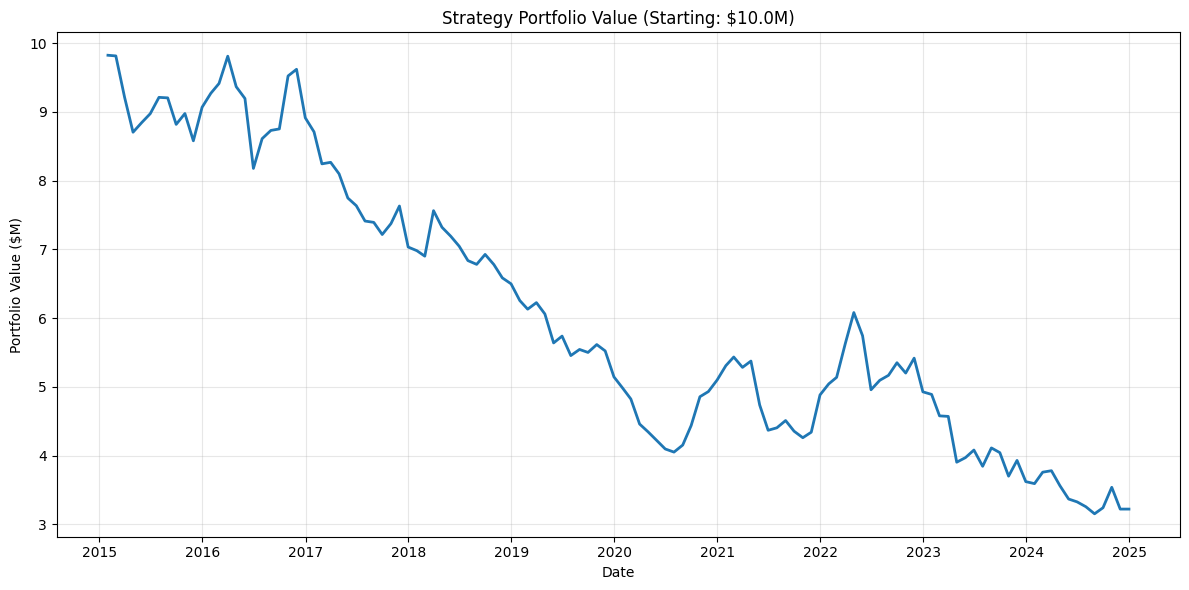

,month_end,permno,ticker,weight,ret_next,pnl,monthly_returns
0,2015-01-31,10104,ORCL,-0.061334,0.046073,-0.002826,-0.017742
1,2015-01-31,10107,MSFT,-0.121366,0.093069,-0.011295,-0.017742
2,2015-01-31,11404,ED,0.046639,-0.079244,-0.003696,-0.017742
3,2015-01-31,12490,IBM,-0.052208,0.063466,-0.003313,-0.017742
4,2015-01-31,12872,MPC,0.039144,0.139432,0.005458,-0.017742
...,...,...,...,...,...,...,...
5995,2024-12-31,87034,LII,-0.006222,<NA>,<NA>,0.0
5996,2024-12-31,89269,CNC,0.061312,<NA>,<NA>,0.0
5997,2024-12-31,91103,UAL,0.030387,<NA>,<NA>,0.0
5998,2024-12-31,92108,BX,-0.060204,<NA>,<NA>,0.0


In [92]:
# Starting capital
START_CAPITAL = 10_000_000

# Shift returns back one month so they line up with the formation month
returns_next = panel['ret'].reset_index()
returns_next['month_end'] = returns_next['month_end'] - pd.offsets.MonthEnd(1)
returns_next = returns_next[['month_end', 'permno', 'ret']].rename(columns={'ret': 'ret_next'})

# Merge positions with next-month returns
bt_df = positions.reset_index().merge(
    returns_next,
    on=['month_end', 'permno'],
    how='left'
)

# Portfolio return per position = weight * return
bt_df['pnl'] = bt_df['weight'] * bt_df['ret_next']

# Aggregate to monthly portfolio return
monthly_returns = bt_df.groupby('month_end')['pnl'].sum()
bt_df = bt_df.merge(monthly_returns.rename('monthly_returns'), on='month_end', how='left')

# Cumulative return and portfolio value
cumulative = (1 + monthly_returns).cumprod() - 1
portfolio_value = START_CAPITAL * (1 + cumulative)

# Summary stats
print(f"Starting capital: ${START_CAPITAL:,.0f}")
print(f"Ending value: ${portfolio_value.iloc[-1]:,.0f}")
print(f"Total return: {cumulative.iloc[-1]:.2%}")
print(f"Annual Sharpe: {(monthly_returns.mean() / monthly_returns.std()) * np.sqrt(12):.2f}")
print(f"Max drawdown: {((cumulative.cummax() - cumulative) / (cumulative.cummax() + 1)).max():.2%}")

# Plot cumulative return
plt.figure(figsize=(12, 6))
plt.plot(portfolio_value.index, portfolio_value.values / 1_000_000, linewidth=2)
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($M)')
plt.title(f'Strategy Portfolio Value (Starting: ${START_CAPITAL/1_000_000:.1f}M)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(bt_df)
bt_df.to_csv('backtest-result.csv')